# XGBoost v4 — Optuna Search on v3 Data

Same preprocessing as v3. Same Optuna hyperparameter search as v4_prepfeat_disc.
Use this to find optimal parameters before the new feature dataset is ready.

**TEST_RUN flag** — set to `True` for a fast pipeline check (3 trials, 50 trees max).
Set to `False` for the real search (50 trials, full parameter space).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Test run flag ─────────────────────────────────────────────────────────────
# Set TEST_RUN = True for a quick pipeline check:
#   - Optuna: 3 trials instead of 50
#   - n_estimators capped at 50 trees (fast fit per trial)
#   - CV and plots still run in full so you can verify the whole pipeline
#
# Set TEST_RUN = False for the real search.

TEST_RUN = False   # ← flip to False for full run

In [3]:
df = pd.read_csv('../../Data_Processing/preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])
df = df.sort_values("datetime_utc12").reset_index(drop=True)

target_col = "el_price_dol_MWh_OTA2201"
print("Shape:", df.shape)

Shape: (52585, 81)


In [4]:
# ── Preprocessing (identical to v3) ──────────────────────────────────────────

df = df.ffill()

cols_to_shift_24h = [
    c for c in df.columns if "el_price" in c and c != target_col
] + [
    "Coal","Diesel","Ele","Gas","Geo","Hydro","Solar","Wind","Wood",
    "demand_GWh_CNI","demand_GWh_LNI","demand_GWh_LSI","demand_GWh_UNI","demand_GWh_USI",
    "avg_flow_MW","peak_flow_MW","Direction"
]
for col in cols_to_shift_24h:
    df[f"{col}_lag24"] = df[col].shift(24)
    df = df.drop(columns=[col])

df["hour"]       = df["datetime_utc12"].dt.hour
df["dayofweek"]  = df["datetime_utc12"].dt.dayofweek
df["month"]      = df["datetime_utc12"].dt.month
df["dayofyear"]  = df["datetime_utc12"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)
df["hour_sin"]   = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]   = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]    = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]    = np.cos(2*np.pi*df["dayofweek"]/7)
df["month_sin"]  = np.sin(2*np.pi*df["month"]/12)
df["month_cos"]  = np.cos(2*np.pi*df["month"]/12)

df["target_lag_24h"]   = df[target_col].shift(24)
df["target_lag_168h"]  = df[target_col].shift(168)
df["target_lag_8760h"] = df[target_col].shift(8760)

for window in [24, 168, 8760]:
    shifted = df[target_col].shift(1)
    df[f"rolling_mean_{window}h"] = shifted.rolling(window).mean()
    df[f"rolling_std_{window}h"]  = shifted.rolling(window).std()

rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Rows after cleanup: {len(df)}  (removed {rows_before - len(df)})")

Rows after cleanup: 43825  (removed 8760)


In [5]:
exclude_cols = ["datetime_utc12", target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df[target_col]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (43825, 99)


In [6]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Train: {X_train.shape}  {df['datetime_utc12'].iloc[0].date()} → {df['datetime_utc12'].iloc[split_index-1].date()}")
print(f"Test : {X_test.shape}   {df['datetime_utc12'].iloc[split_index].date()} → {df['datetime_utc12'].iloc[-1].date()}")

Train: (35060, 99)  2020-01-01 → 2023-12-31
Test : (8765, 99)   2023-12-31 → 2024-12-31


In [7]:
# ── Optuna Hyperparameter Search ──────────────────────────────────────────────
#
# 3 validation windows of 3 consecutive months each, covering different regimes:
#   Summer : Jan–Mar 2022
#   Fall   : Apr–Jun 2022
#   Winter : Jul–Sep 2022
#
# TEST_RUN = True  → 3 trials, n_estimators fixed at 50  (pipeline check)
# TEST_RUN = False → 50 trials, full parameter space       (real search)

SEARCH_WINDOWS = [
    ("2022-01-01", "2022-04-01"),   # NZ summer  (3 months)
    ("2022-04-01", "2022-07-01"),   # NZ fall    (3 months)
    ("2022-07-01", "2022-10-01"),   # NZ winter  (3 months)
]

N_TRIALS  = 3   if TEST_RUN else 50
N_EST_MIN = 50  if TEST_RUN else 100
N_EST_MAX = 50  if TEST_RUN else 500

if TEST_RUN:
    print("⚠️  TEST RUN — 3 trials, 50 estimators fixed. Flip TEST_RUN = False for full search.\n")

# Build custom CV splits
train_dates = df["datetime_utc12"].iloc[:split_index].reset_index(drop=True)

custom_splits = []
for start_str, end_str in SEARCH_WINDOWS:
    start_ts = pd.Timestamp(start_str)
    end_ts   = pd.Timestamp(end_str)
    val_mask   = (train_dates >= start_ts) & (train_dates < end_ts)
    train_mask = train_dates < start_ts
    val_idx    = np.where(val_mask.values)[0]
    train_idx  = np.where(train_mask.values)[0]
    if len(val_idx) == 0:
        print(f"WARNING: no data for {start_str} → {end_str}")
    else:
        custom_splits.append((train_idx, val_idx))
        print(f"{start_str} → {end_str}:  train={len(train_idx):,}  val={len(val_idx):,}")

print(f"\n{len(custom_splits)} windows ready — running {N_TRIALS} trials...\n")

def objective(trial):
    params = {
        "learning_rate":    trial.suggest_float("learning_rate",    0.01, 0.3,      log=True),
        "subsample":        trial.suggest_float("subsample",        0.6,  1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6,  1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha",        0.0,  10.0),
        "gamma":            trial.suggest_float("gamma",            0.0,  2.0),
        "n_estimators":     trial.suggest_int(  "n_estimators",     N_EST_MIN, N_EST_MAX, step=50),
        "max_depth":        trial.suggest_int(  "max_depth",        3,    8),
        "min_child_weight": trial.suggest_int(  "min_child_weight", 1,    10),
        "random_state": 42,
        "n_jobs": -1,
    }
    fold_maes = []
    for train_idx, val_idx in custom_splits:
        m = XGBRegressor(**params)
        m.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = np.clip(m.predict(X_train.iloc[val_idx]), 0, None)
        fold_maes.append(mean_absolute_error(y_train.iloc[val_idx], pred))
    return np.mean(fold_maes)

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

BEST_PARAMS = study.best_params
BEST_PARAMS["random_state"] = 42
BEST_PARAMS["n_jobs"]       = -1

print(f"\nBest mean MAE : {study.best_value:.4f}")
print("Best parameters:")
for k, v in sorted(BEST_PARAMS.items()):
    if k not in ["random_state", "n_jobs"]:
        print(f"  {k:<22}: {v}")

2022-01-01 → 2022-04-01:  train=17,544  val=2,160
2022-04-01 → 2022-07-01:  train=19,704  val=2,184
2022-07-01 → 2022-10-01:  train=21,888  val=2,208

3 windows ready — running 50 trials...



Best trial: 32. Best value: 39.3075: 100%|██████████| 50/50 [09:42<00:00, 11.64s/it]


Best mean MAE : 39.3075
Best parameters:
  colsample_bytree      : 0.8479100023609782
  gamma                 : 0.25171297243784646
  learning_rate         : 0.042837330180309975
  max_depth             : 3
  min_child_weight      : 5
  n_estimators          : 450
  reg_alpha             : 3.3958370334581254
  subsample             : 0.9031628293804717


In [8]:
# ── Optuna visualisation (skipped in test run) ────────────────────────────────

if TEST_RUN:
    print("Skipping Optuna plots in test run (too few trials to be meaningful).")
else:
    try:
        from optuna.visualization import plot_optimization_history, plot_param_importances
        plot_optimization_history(study).show()
        plot_param_importances(study).show()
    except ImportError:
        print("pip install plotly  to enable Optuna plots")
        trials_df = study.trials_dataframe()
        print(trials_df.sort_values("value").head(5)[
            ["number","value"] + [c for c in trials_df.columns if c.startswith("params_")]
        ].to_string(index=False))

pip install plotly  to enable Optuna plots
 number     value  params_colsample_bytree  params_gamma  params_learning_rate  params_max_depth  params_min_child_weight  params_n_estimators  params_reg_alpha  params_subsample
     32 39.307470                 0.847910      0.251713              0.042837                 3                        5                  450          3.395837          0.903163
     25 39.322464                 0.857839      1.289096              0.036868                 3                        8                  350          2.845427          0.952010
     44 39.323766                 0.806814      0.213106              0.032667                 3                        7                  500          1.775327          0.903765
     27 39.358529                 0.919911      0.003870              0.039226                 3                        9                  350          0.855017          0.949097
     42 39.438231                 0.843958      0.300873      

In [9]:
# ── 12-Fold Expanding-Window CV ───────────────────────────────────────────────

tscv = TimeSeriesSplit(n_splits=12, test_size=720)
fold_results = []

print(f"{'Fold':>4}  {'Month':>10}  {'MAE model':>10}  {'MAE naive':>10}  {'RMSE model':>11}  {'RMSE naive':>11}  {'MASE':>6}")
print("-" * 72)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    m = XGBRegressor(**BEST_PARAMS)
    m.fit(X_tr, y_tr)
    y_model = np.clip(m.predict(X_te), 0, None)
    y_naive = X_te["target_lag_24h"].values

    mae_m  = mean_absolute_error(y_te, y_model)
    mae_n  = mean_absolute_error(y_te, y_naive)
    rmse_m = np.sqrt(mean_squared_error(y_te, y_model))
    rmse_n = np.sqrt(mean_squared_error(y_te, y_naive))
    mase   = mae_m / mae_n

    timestamps  = df["datetime_utc12"].iloc[test_idx].values
    month_label = pd.Timestamp(timestamps[0]).strftime("%b %Y")

    fold_results.append({
        "fold":       fold,
        "month":      month_label,
        "timestamps": timestamps,
        "y_actual":   y_te.values,
        "y_model":    y_model,
        "y_naive":    y_naive,
        "mae_model":  mae_m,
        "mae_naive":  mae_n,
        "rmse_model": rmse_m,
        "rmse_naive": rmse_n,
        "mase":       mase,
    })

    print(f"{fold:>4}  {month_label:>10}  {mae_m:>10.2f}  {mae_n:>10.2f}  "
          f"{rmse_m:>11.2f}  {rmse_n:>11.2f}  {mase:>6.3f}")

Fold       Month   MAE model   MAE naive   RMSE model   RMSE naive    MASE
------------------------------------------------------------------------
   1    Jan 2024       42.52       58.95        62.85        92.48   0.721
   2    Feb 2024       46.26       67.92        68.12       103.88   0.681
   3    Mar 2024       30.81       40.17        41.40        56.58   0.767
   4    Apr 2024       38.33       42.61        50.79        61.04   0.899
   5    May 2024       69.86       95.20       245.19       327.57   0.734
   6    Jun 2024       35.13       41.62        51.82        57.19   0.844
   7    Jul 2024       60.40       75.06        96.13       122.08   0.805
   8    Aug 2024      129.67      103.60       173.87       152.19   1.252
   9    Sep 2024       40.07       54.34        91.71       128.11   0.737
  10    Oct 2024       23.54       27.96        30.57        40.99   0.842
  11    Nov 2024       21.80       30.64        30.74        47.11   0.711
  12    Dec 2024       25.4

In [10]:
# ── Summary Table ─────────────────────────────────────────────────────────────

summary = pd.DataFrame([{
    "Month":       r["month"],
    "MAE model":   r["mae_model"],
    "MAE naive":   r["mae_naive"],
    "RMSE model":  r["rmse_model"],
    "RMSE naive":  r["rmse_naive"],
    "MASE":        r["mase"],
    "Beats naive": "✓" if r["mase"] < 1 else "✗"
} for r in fold_results])

avg_row = pd.DataFrame([{
    "Month":       "AVERAGE",
    "MAE model":   summary["MAE model"].mean(),
    "MAE naive":   summary["MAE naive"].mean(),
    "RMSE model":  summary["RMSE model"].mean(),
    "RMSE naive":  summary["RMSE naive"].mean(),
    "MASE":        summary["MASE"].mean(),
    "Beats naive": f"{(summary['MASE'] < 1).sum()} / 12"
}])

pd.set_option("display.float_format", "{:.2f}".format)
print(pd.concat([summary, avg_row], ignore_index=True).to_string(index=False))

   Month  MAE model  MAE naive  RMSE model  RMSE naive  MASE Beats naive
Jan 2024      42.52      58.95       62.85       92.48  0.72           ✓
Feb 2024      46.26      67.92       68.12      103.88  0.68           ✓
Mar 2024      30.81      40.17       41.40       56.58  0.77           ✓
Apr 2024      38.33      42.61       50.79       61.04  0.90           ✓
May 2024      69.86      95.20      245.19      327.57  0.73           ✓
Jun 2024      35.13      41.62       51.82       57.19  0.84           ✓
Jul 2024      60.40      75.06       96.13      122.08  0.80           ✓
Aug 2024     129.67     103.60      173.87      152.19  1.25           ✗
Sep 2024      40.07      54.34       91.71      128.11  0.74           ✓
Oct 2024      23.54      27.96       30.57       40.99  0.84           ✓
Nov 2024      21.80      30.64       30.74       47.11  0.71           ✓
Dec 2024      25.45      36.89      159.91      230.59  0.69           ✓
 AVERAGE      46.99      56.25       91.93      118

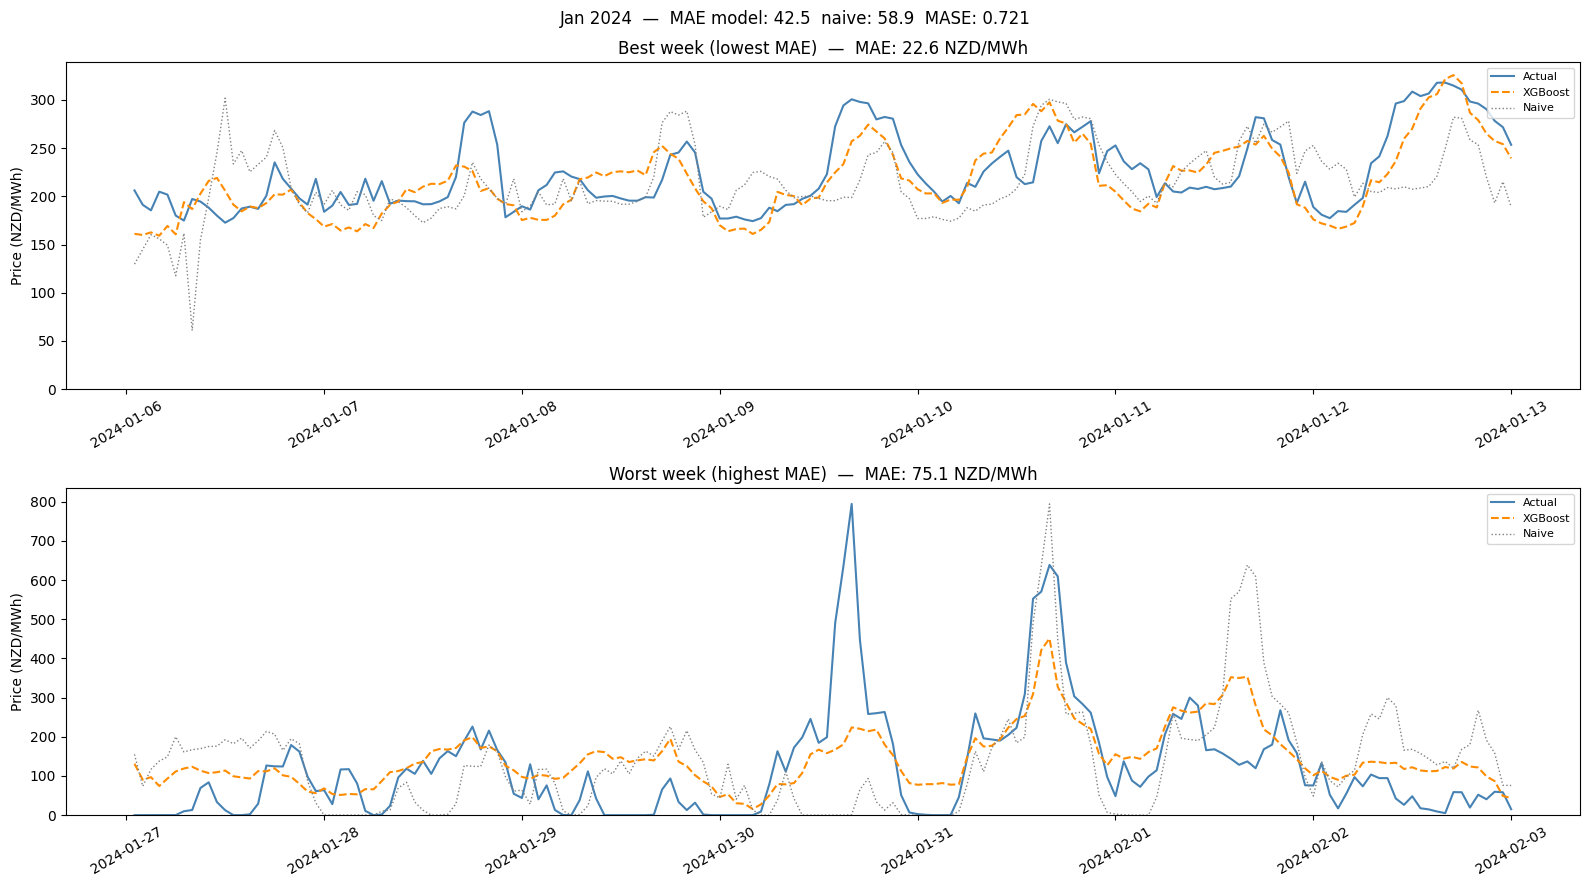

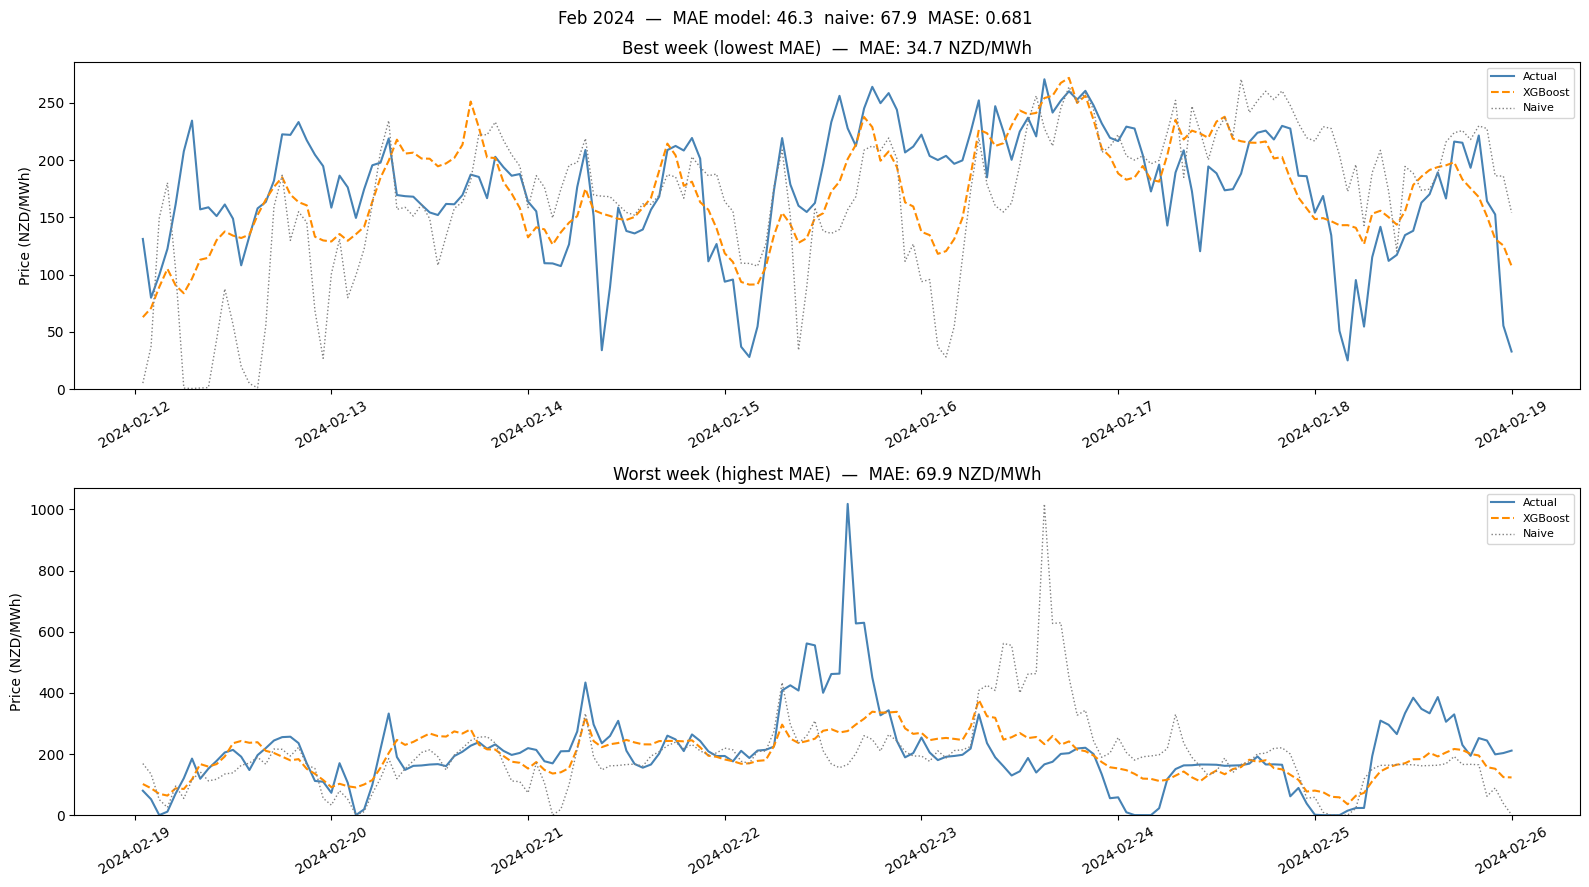

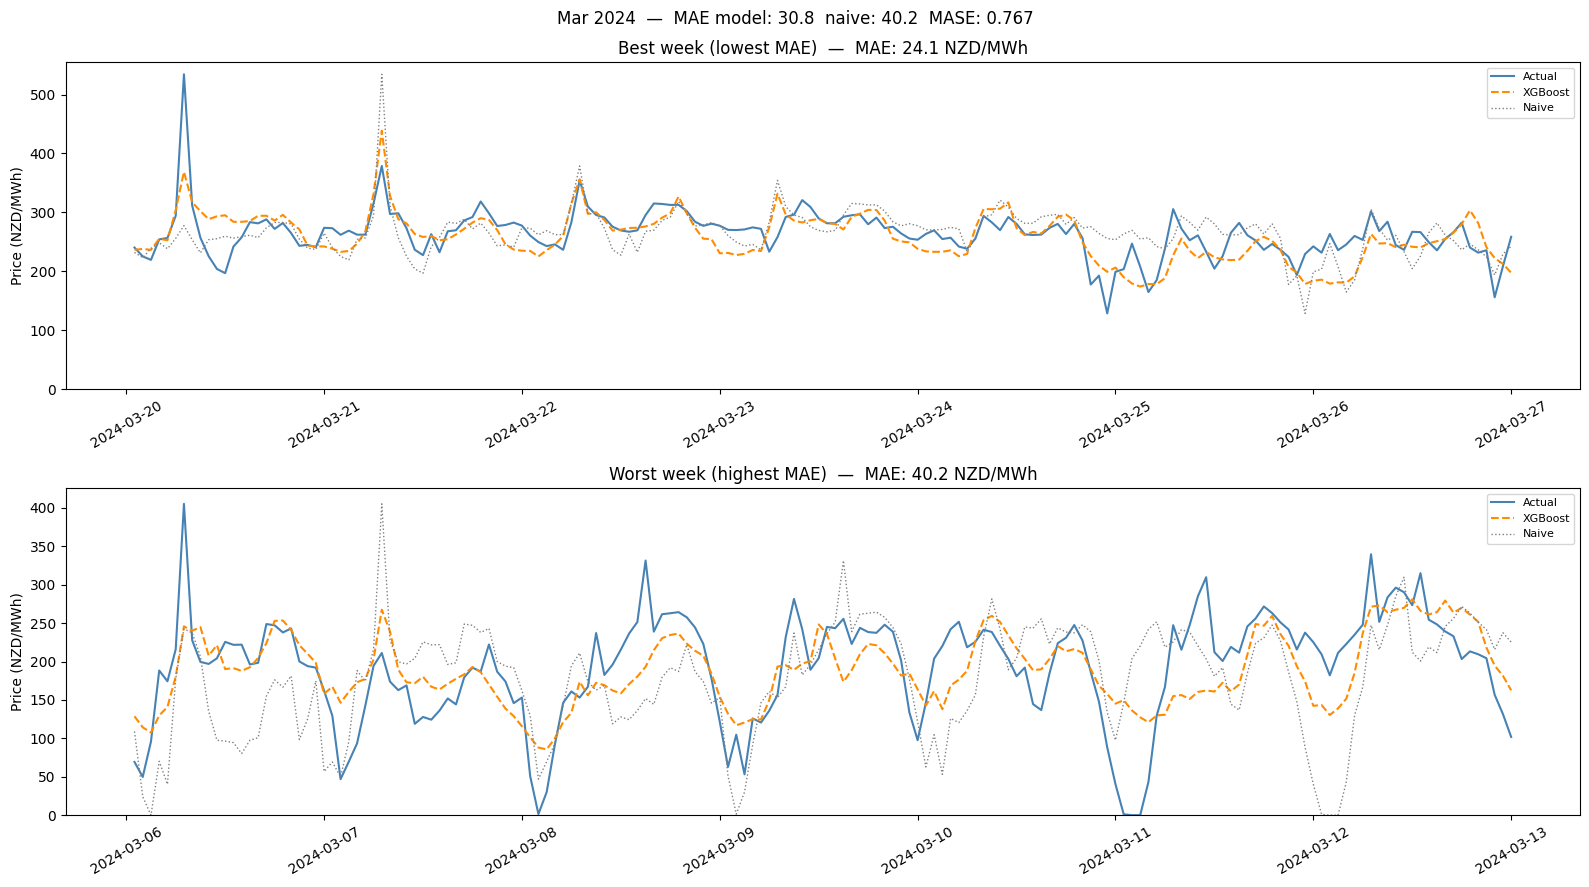

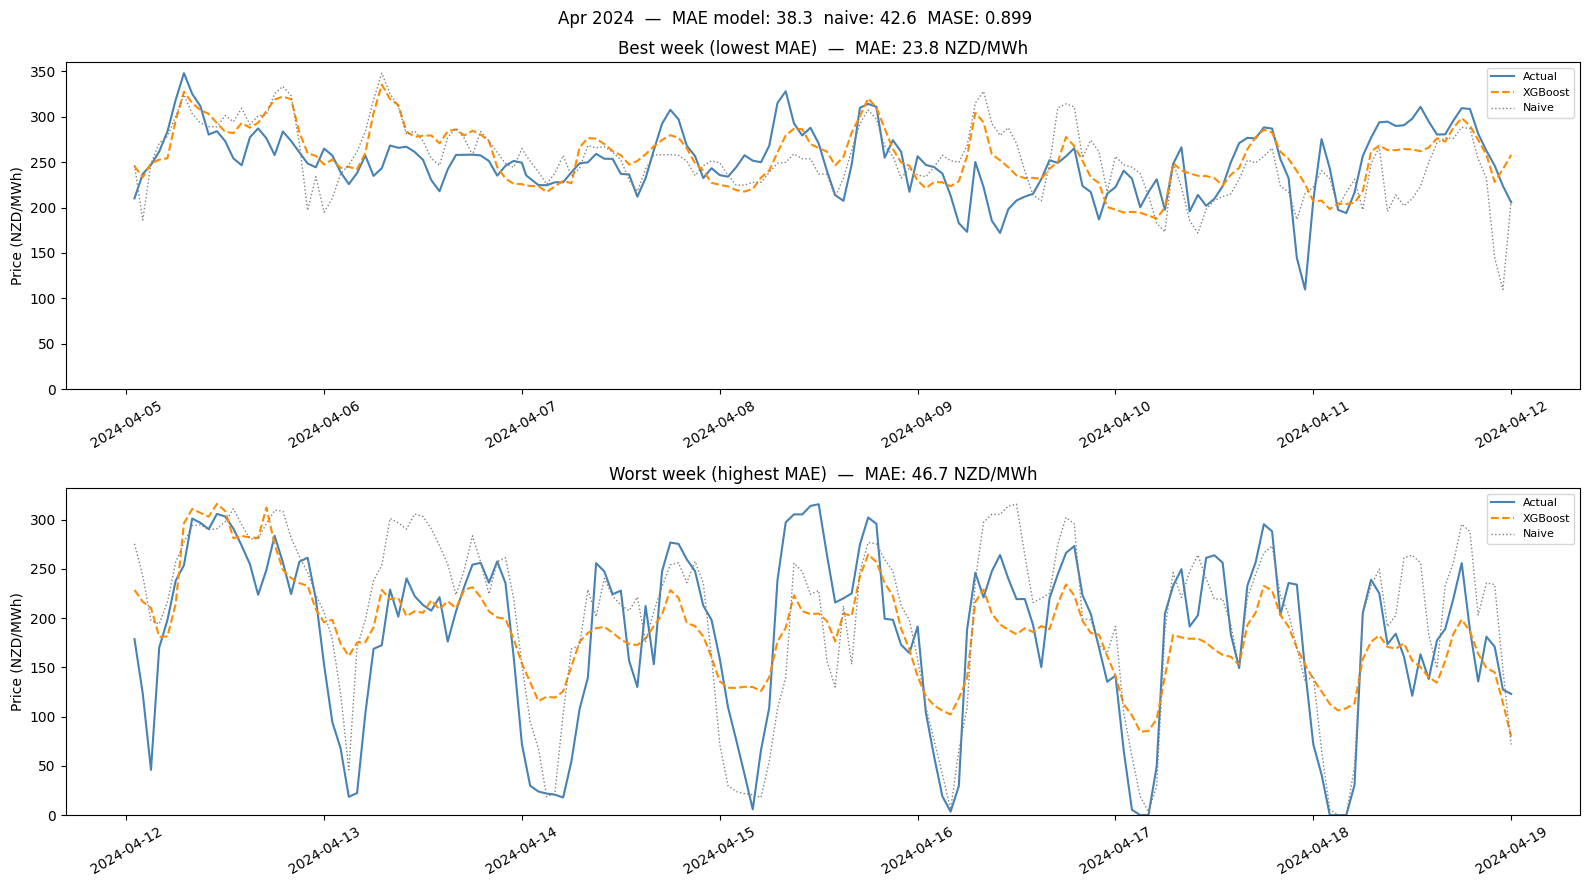

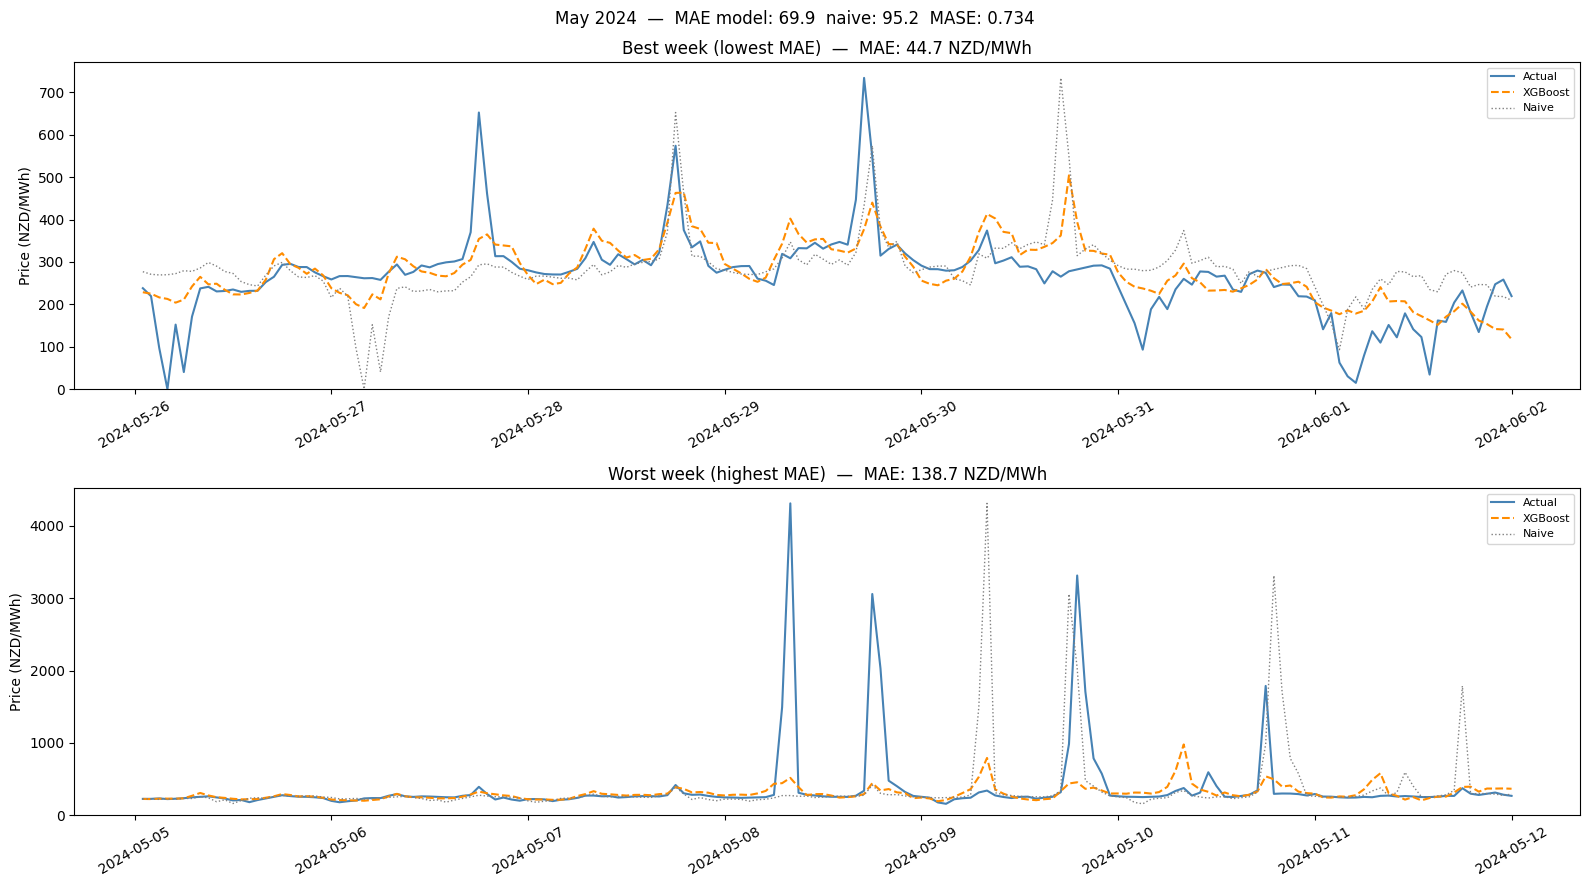

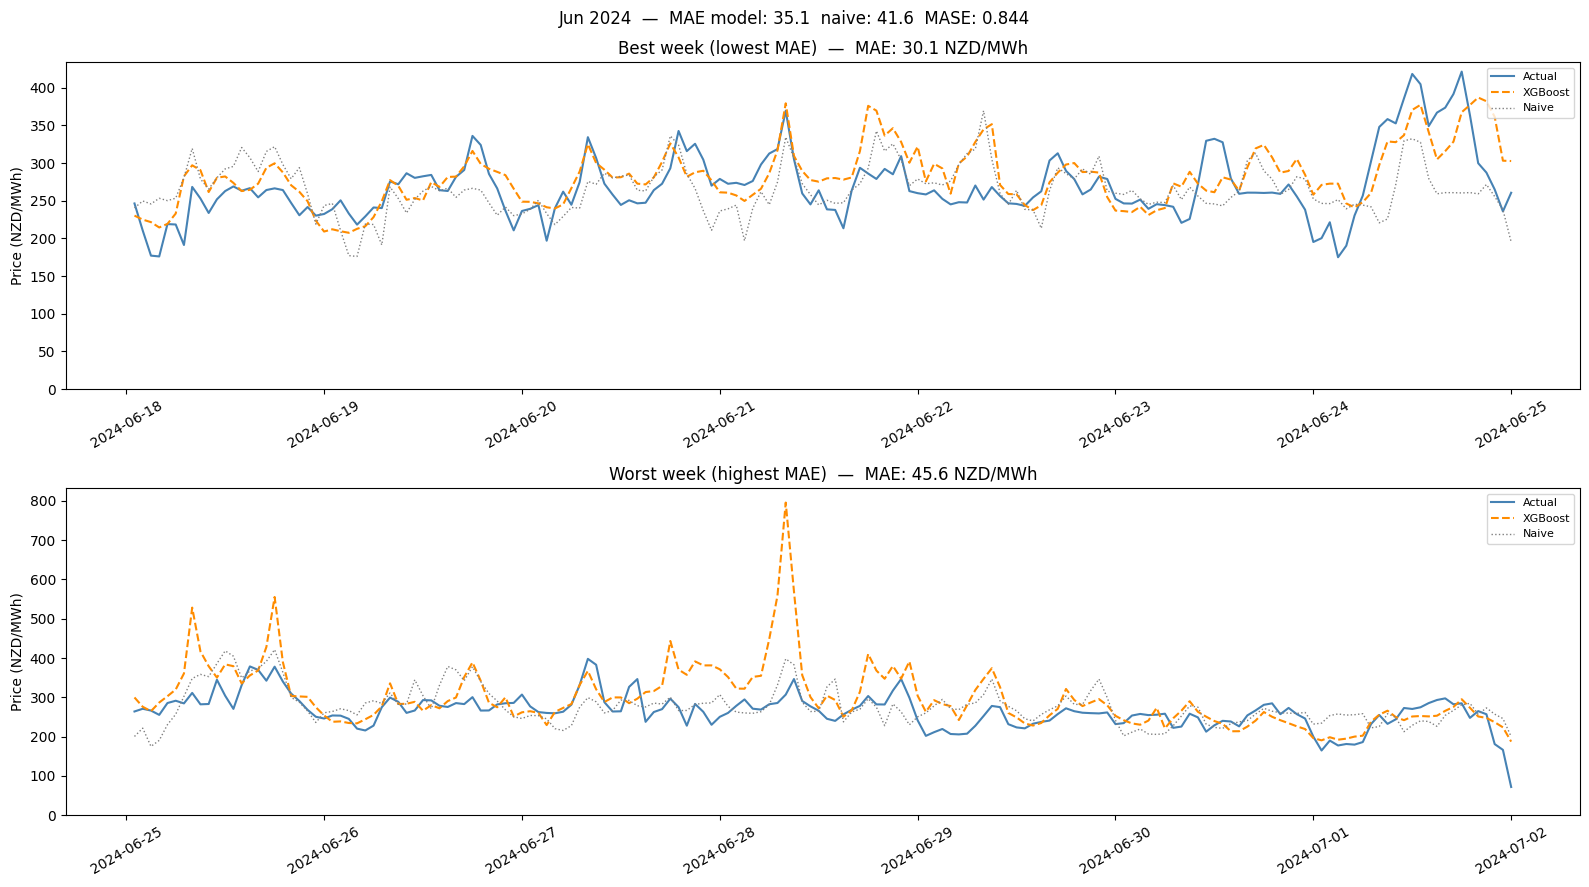

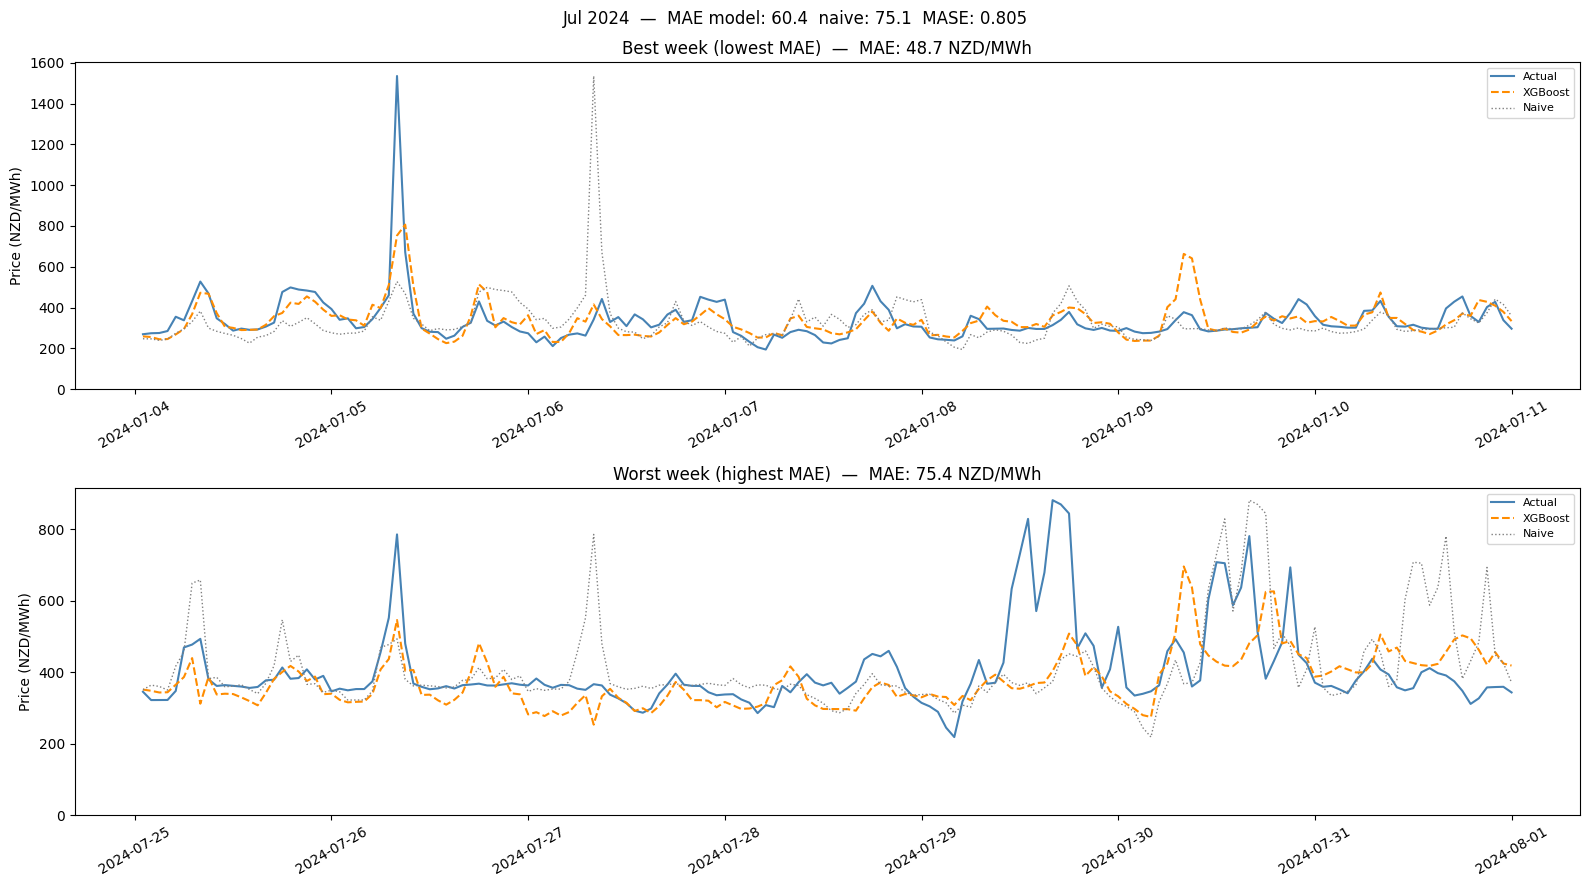

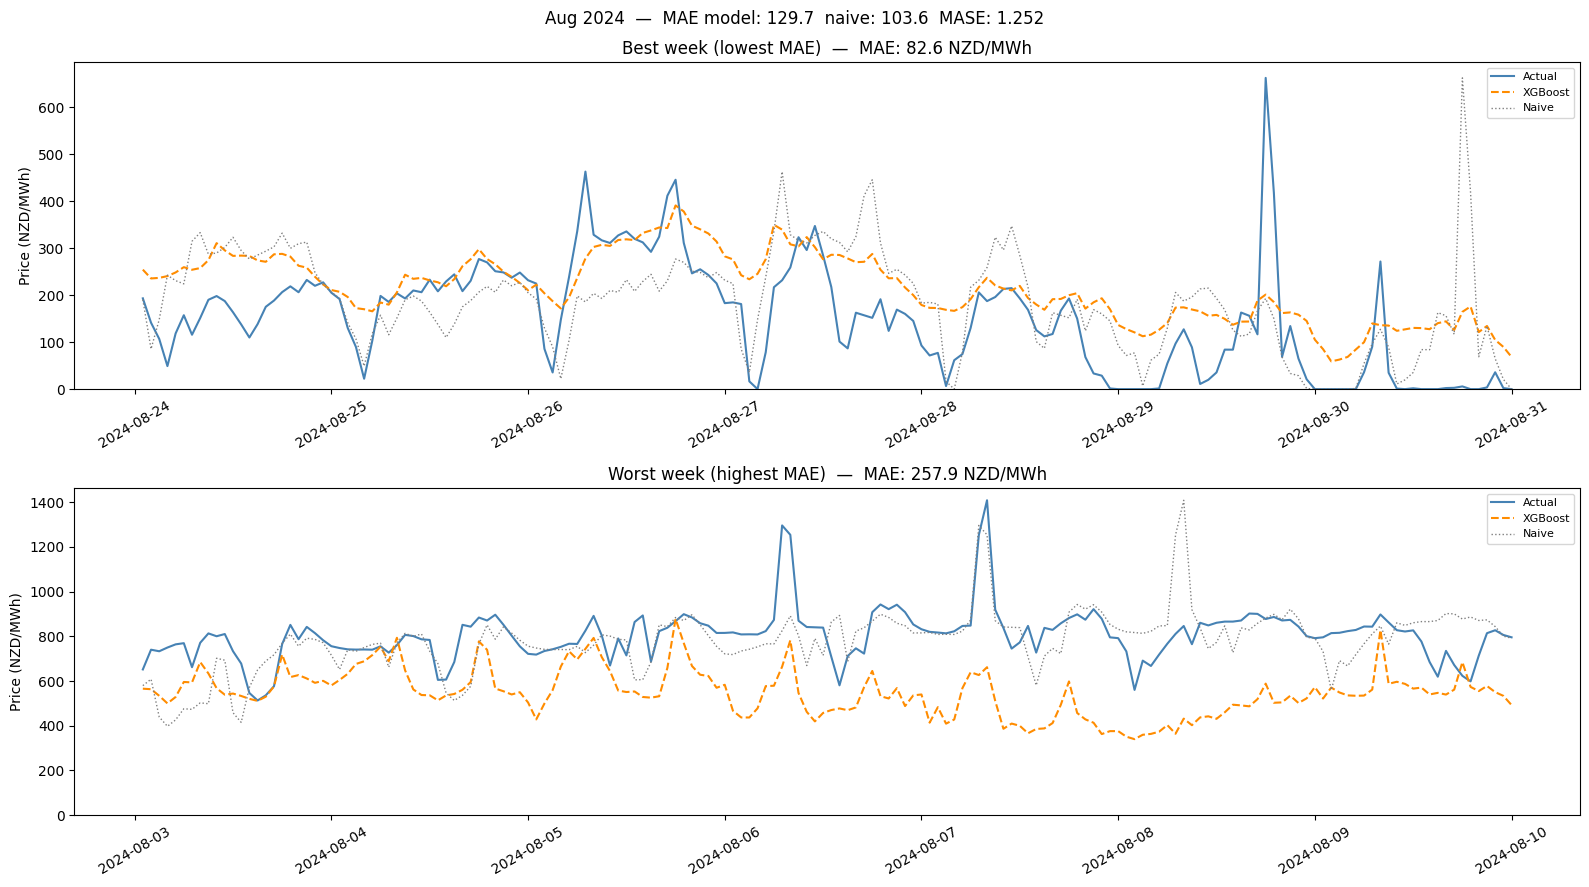

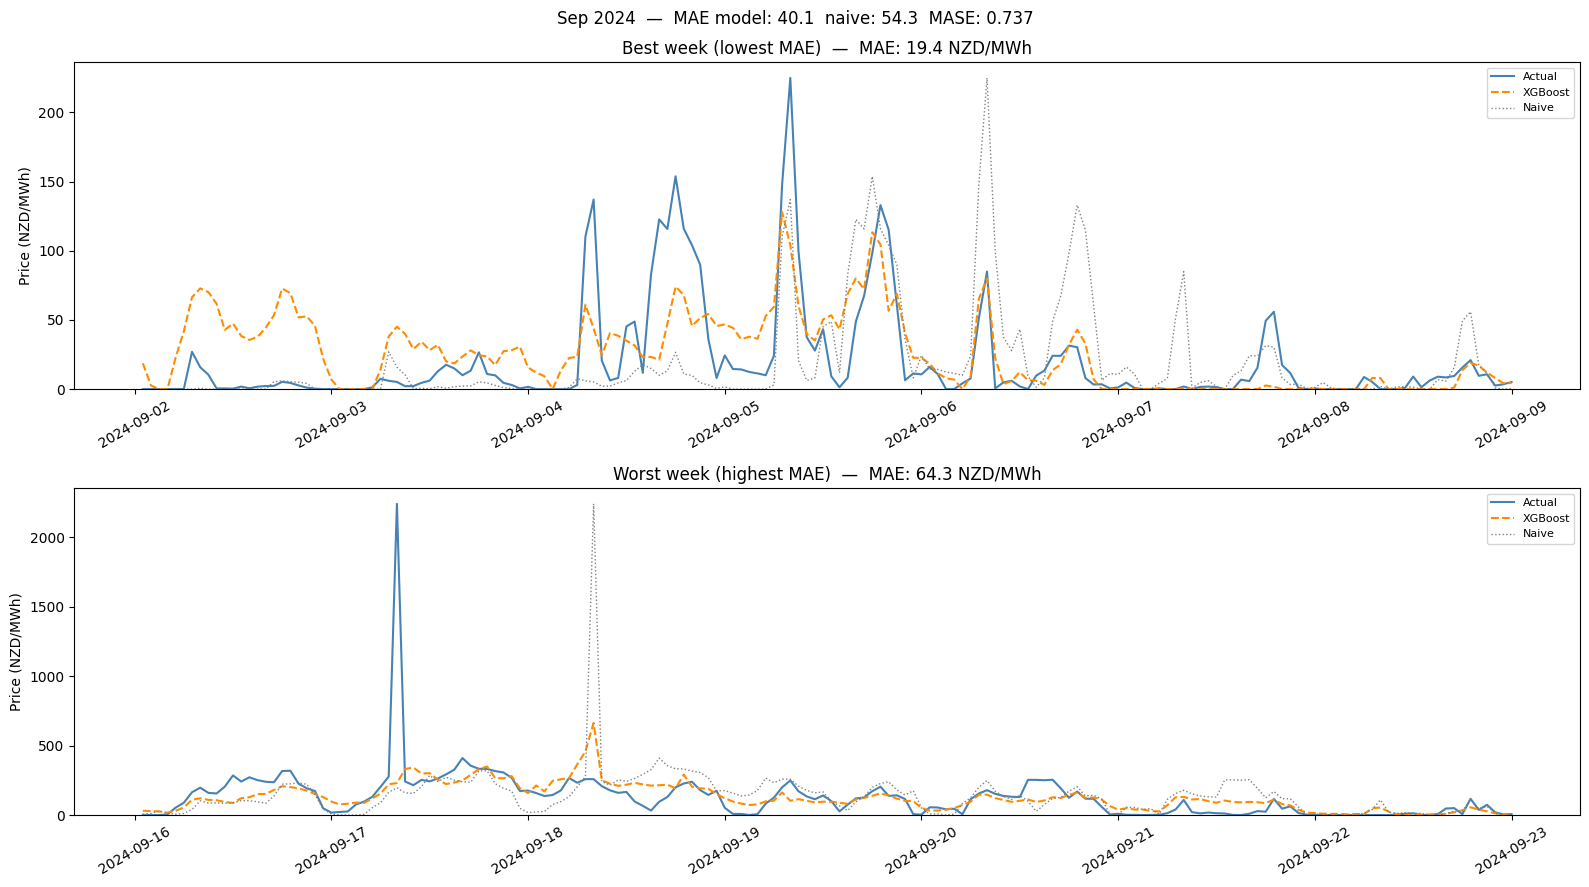

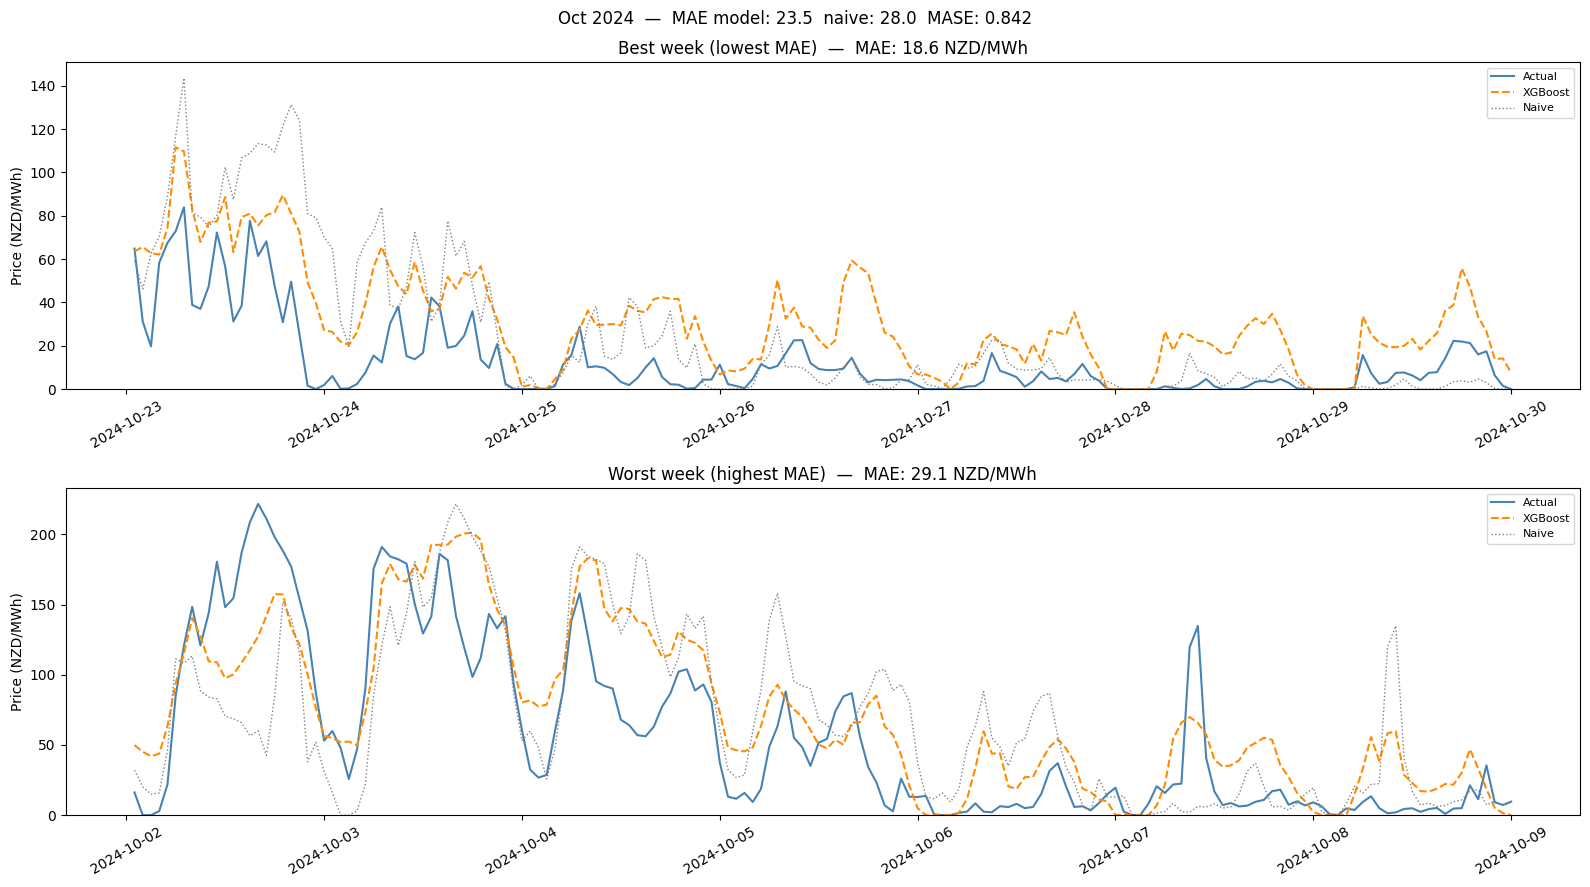

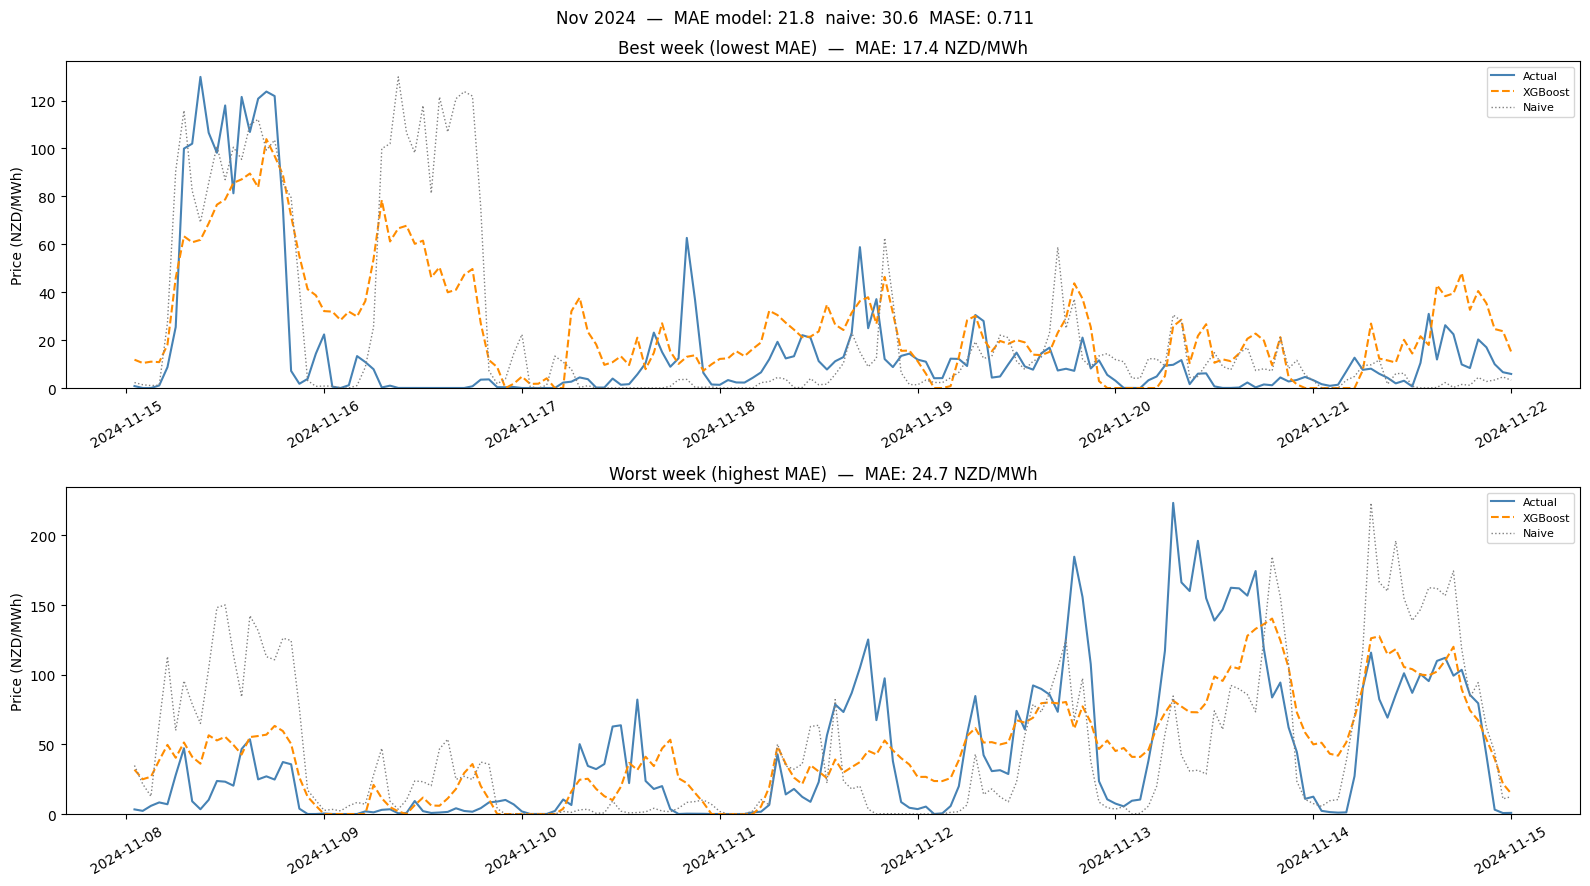

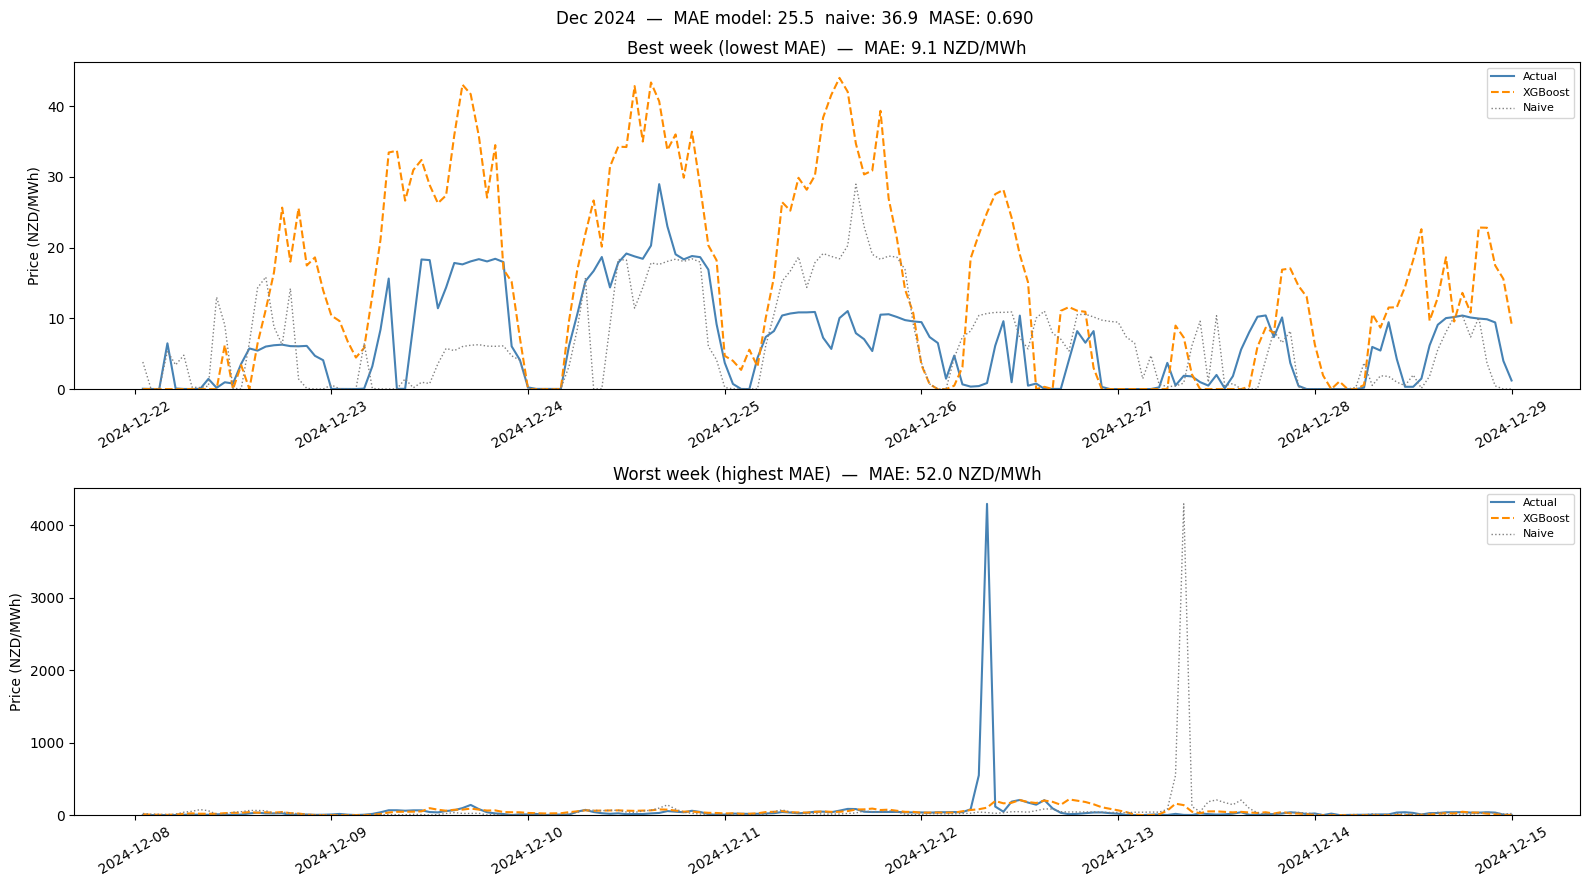

In [11]:
# ── Monthly Visualisation — Best & Worst Week per Fold ────────────────────────

def find_best_worst_weeks(y_actual, y_model, week_size=168):
    n_weeks = len(y_actual) // week_size
    week_maes = [(mean_absolute_error(y_actual[w*week_size:(w+1)*week_size],
                                      y_model [w*week_size:(w+1)*week_size]),
                  w*week_size, (w+1)*week_size) for w in range(n_weeks)]
    return min(week_maes, key=lambda x: x[0]), max(week_maes, key=lambda x: x[0])


for r in fold_results:
    best, worst = find_best_worst_weeks(r["y_actual"], r["y_model"])

    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    fig.suptitle(
        f"{r['month']}  —  MAE model: {r['mae_model']:.1f}  "
        f"naive: {r['mae_naive']:.1f}  MASE: {r['mase']:.3f}",
        fontsize=12
    )
    for ax, (mae, s, e), label in zip(
        axes, [best, worst],
        ["Best week (lowest MAE)", "Worst week (highest MAE)"]
    ):
        ts  = r["timestamps"][s:e]
        ax.plot(ts, r["y_actual"][s:e], label="Actual",  color="steelblue",  linewidth=1.5)
        ax.plot(ts, r["y_model"] [s:e], label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--")
        ax.plot(ts, r["y_naive"] [s:e], label="Naive",   color="gray",       linewidth=1.0, linestyle=":")
        ax.set_title(f"{label}  —  MAE: {mae:.1f} NZD/MWh")
        ax.set_ylabel("Price (NZD/MWh)")
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=8, loc="upper right")
        ax.tick_params(axis="x", labelrotation=30)
    plt.tight_layout()
    plt.show()

In [12]:
# ── Final Model ───────────────────────────────────────────────────────────────

xgb_model = XGBRegressor(**BEST_PARAMS)
xgb_model.fit(X_train, y_train)

y_pred = np.clip(xgb_model.predict(X_test), 0, None)

print(f"Final model  {'[TEST RUN]' if TEST_RUN else ''}")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"  R²   : {r2_score(y_test, y_pred):.4f}")

Final model  
  MAE  : 49.7515
  RMSE : 118.2990
  R²   : 0.6059


                       feature  importance
el_price_dol_MWh_RDF2201_lag24        0.17
el_price_dol_MWh_KIK2201_lag24        0.14
              rolling_mean_24h        0.11
el_price_dol_MWh_WKM2201_lag24        0.05
    SI_TKA__active_storage_mm³        0.03
            rolling_mean_8760h        0.02
                target_lag_24h        0.02
               target_lag_168h        0.02
             avg_flow_MW_lag24        0.02
          SI_TKA__lake_level_m        0.02
               auckland_temp_c        0.02
          demand_GWh_UNI_lag24        0.01
el_price_dol_MWh_HAY2201_lag24        0.01
             rolling_std_8760h        0.01
el_price_dol_MWh_SFD2201_lag24        0.01
                          hour        0.01
          SI_PKI__lake_level_m        0.01
el_price_dol_MWh_ISL2201_lag24        0.01
          SI_MAN__lake_level_m        0.01
          demand_GWh_CNI_lag24        0.01


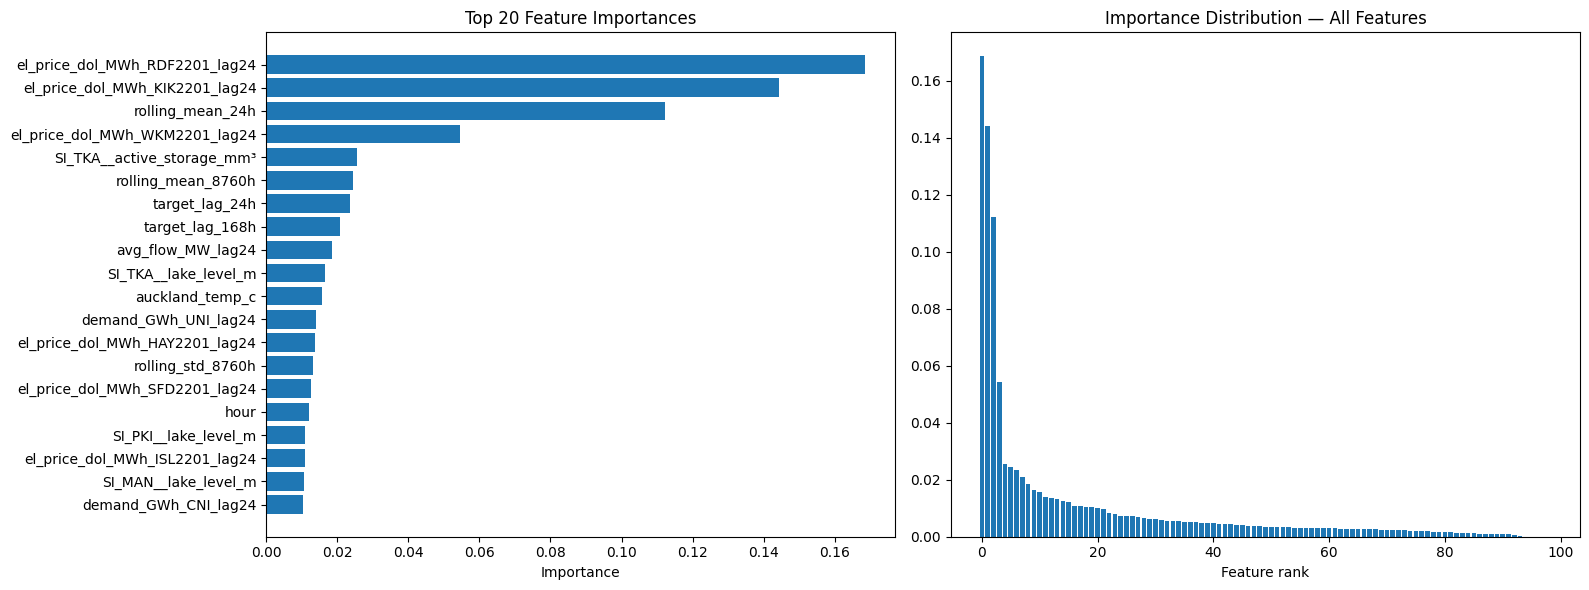

In [13]:
# ── Feature Importance ────────────────────────────────────────────────────────

importance_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top20 = importance_df.head(20)
axes[0].barh(top20["feature"][::-1], top20["importance"][::-1])
axes[0].set_title("Top 20 Feature Importances")
axes[0].set_xlabel("Importance")
axes[1].bar(range(len(importance_df)), importance_df["importance"].values)
axes[1].set_title("Importance Distribution — All Features")
axes[1].set_xlabel("Feature rank")
plt.tight_layout()
plt.show()

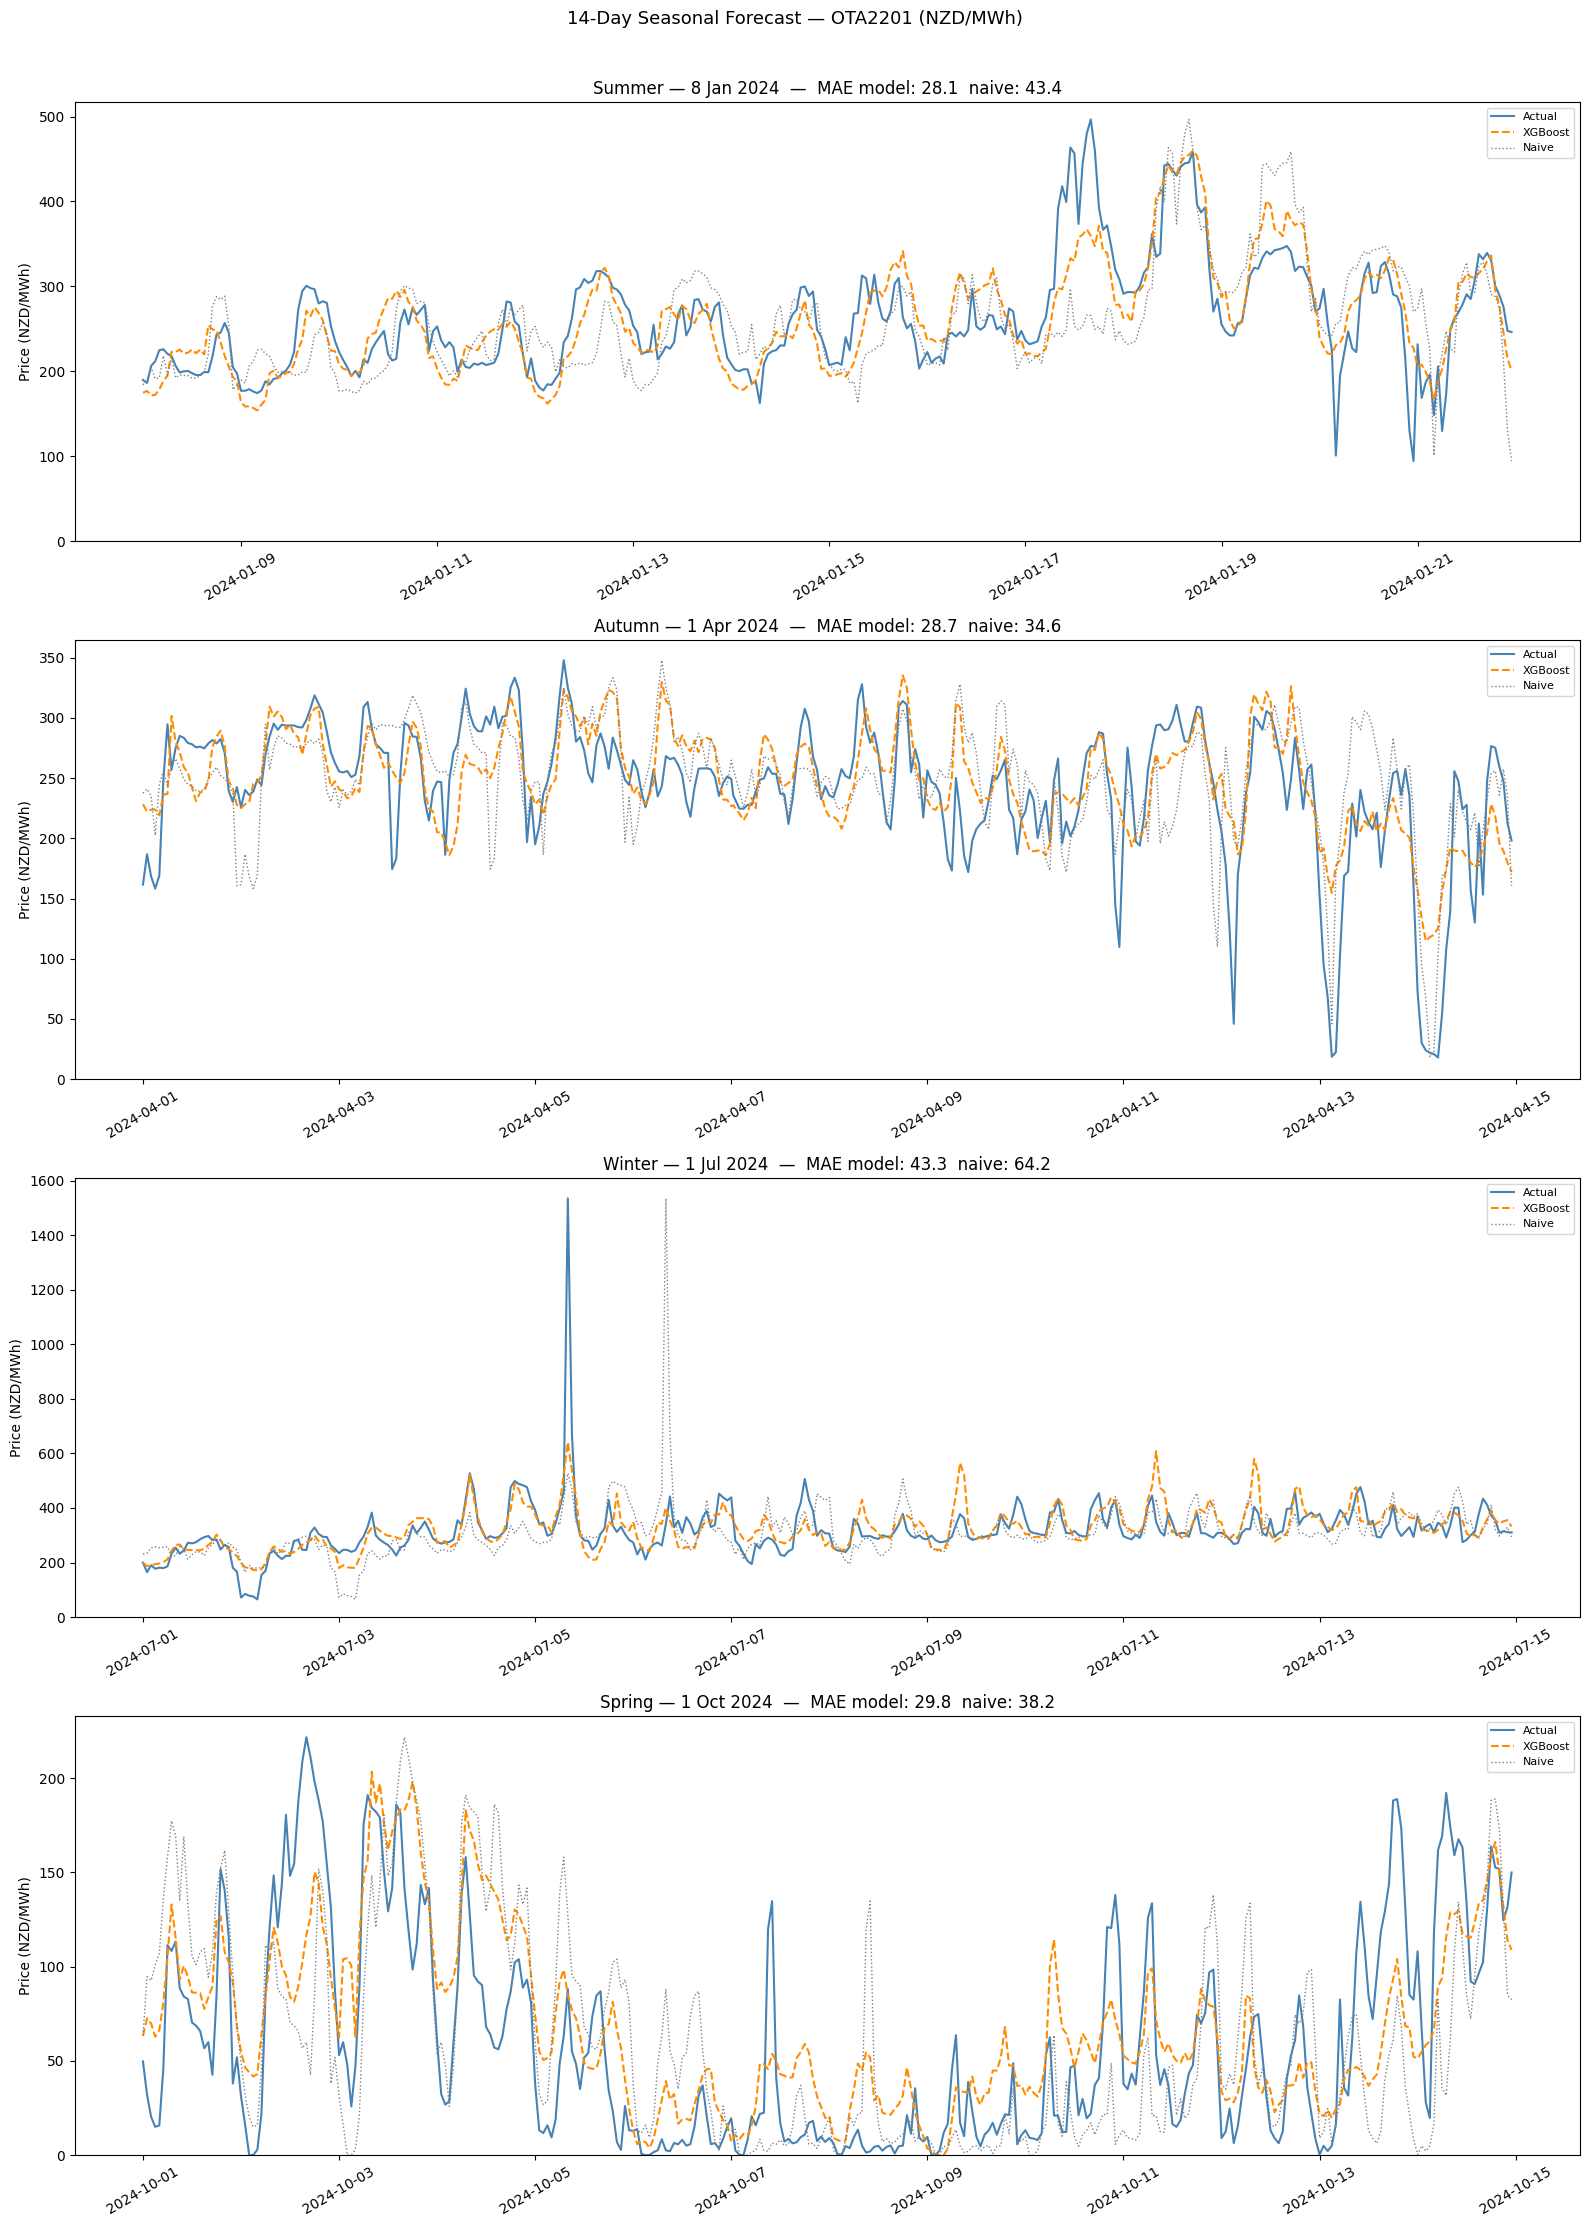

In [14]:
# ── Seasonal 14-Day Forecasts ─────────────────────────────────────────────────

def rolling_forecast(model, start_date, n_days=14):
    start_ts = pd.Timestamp(start_date)
    mask = (
        (df["datetime_utc12"] >= start_ts) &
        (df["datetime_utc12"] <  start_ts + pd.Timedelta(hours=n_days * 24))
    )
    d = df[mask].reset_index(drop=True)
    if len(d) < n_days * 24:
        raise ValueError(f"Not enough data from {start_date}")
    preds = np.clip(model.predict(d[feature_cols].values), 0, None)
    naive = d["target_lag_24h"].values
    return preds, d[target_col].values, d["datetime_utc12"].values, naive


seasons = {
    "Summer — 8 Jan 2024":  "2024-01-08",
    "Autumn — 1 Apr 2024":  "2024-04-01",
    "Winter — 1 Jul 2024":  "2024-07-01",
    "Spring — 1 Oct 2024":  "2024-10-01",
}

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("14-Day Seasonal Forecast — OTA2201 (NZD/MWh)", fontsize=13, y=1.01)

for ax, (label, start) in zip(axes, seasons.items()):
    preds, actuals, ts, naive = rolling_forecast(xgb_model, start)
    mae_m = mean_absolute_error(actuals, preds)
    mae_n = mean_absolute_error(actuals, naive)
    ax.plot(ts, actuals, label="Actual",  color="steelblue",  linewidth=1.5)
    ax.plot(ts, preds,   label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--")
    ax.plot(ts, naive,   label="Naive",   color="gray",       linewidth=1.0, linestyle=":")
    ax.set_title(f"{label}  —  MAE model: {mae_m:.1f}  naive: {mae_n:.1f}")
    ax.set_ylabel("Price (NZD/MWh)")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.show()

In [15]:
# ── Save model ────────────────────────────────────────────────────────────────
# Skipped automatically if TEST_RUN = True (no point saving a test model).

if TEST_RUN:
    print("TEST RUN — model not saved. Flip TEST_RUN = False and re-run to save.")
else:
    timestamp  = datetime.now().strftime("%Y%m%d_%H%M")
    model_name = f"xgb_v4_OTA2201_{timestamp}"
    save_dir   = "./"

    xgb_model.save_model(f"{save_dir}{model_name}.ubj")

    params_to_save = {k: v for k, v in BEST_PARAMS.items()
                      if k not in ["random_state", "n_jobs"]}
    with open(f"{save_dir}{model_name}_params.json", "w") as f:
        json.dump(params_to_save, f, indent=2)

    with open(f"{save_dir}{model_name}_features.txt", "w") as f:
        f.write("\n".join(feature_cols))

    print(f"Saved as : {model_name}")
    print(f"  Weights  : {model_name}.ubj")
    print(f"  Params   : {model_name}_params.json")
    print(f"  Features : {model_name}_features.txt")
    print(f"\nTo reload:")
    print(f"  model = XGBRegressor()")
    print(f"  model.load_model('{model_name}.ubj')")

Saved as : xgb_v4_OTA2201_20260602_1457
  Weights  : xgb_v4_OTA2201_20260602_1457.ubj
  Params   : xgb_v4_OTA2201_20260602_1457_params.json
  Features : xgb_v4_OTA2201_20260602_1457_features.txt

To reload:
  model = XGBRegressor()
  model.load_model('xgb_v4_OTA2201_20260602_1457.ubj')
